# 1. 데이터 불러오기

```
uv add yfinance
```

In [18]:
import yfinance as yf
from datetime import date, timedelta

# 날짜 설정
year = 5
today = date.today()
end_date = today.strftime("%Y-%m-%d")
start_date = today - timedelta(days=365*year)

# 데이터 다운로드
data = yf.download(
    tickers = "009450.KS",
    start = start_date,
    end = end_date
)

data.head()

C:\Users\user\AppData\Local\Temp\ipykernel_54572\3232389257.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,009450.KS,009450.KS,009450.KS,009450.KS,009450.KS
Date,,,,,
2020-09-09,54533.328125,55294.700943,53391.268897,55104.357739,154018
2020-09-10,57102.960938,58816.049766,55009.185703,55389.872109,384979
2020-09-11,57293.300781,58054.673549,55389.868862,56531.928013,153445
2020-09-14,55865.730469,57293.304501,55580.215662,57293.304501,125104
2020-09-15,56246.414062,56531.928855,54438.153712,55865.727673,107441


In [19]:
# 멀티컬럼 지우기
data.columns = data.columns.droplevel(1)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-09-09,54533.328125,55294.700943,53391.268897,55104.357739,154018
2020-09-10,57102.960938,58816.049766,55009.185703,55389.872109,384979
2020-09-11,57293.300781,58054.673549,55389.868862,56531.928013,153445
2020-09-14,55865.730469,57293.304501,55580.215662,57293.304501,125104
2020-09-15,56246.414062,56531.928855,54438.153712,55865.727673,107441


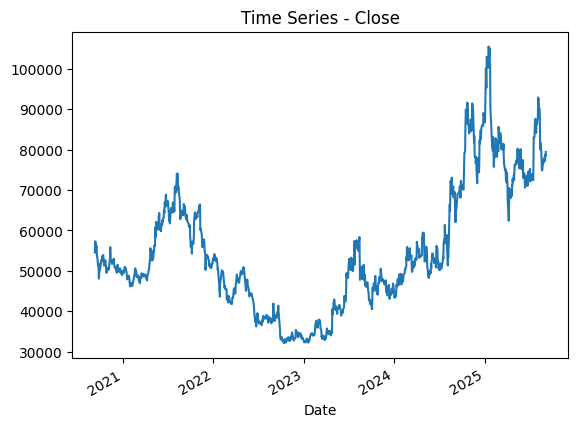

In [20]:
# 데이터 시각화
import matplotlib.pyplot as plt

data["Close"].plot()
plt.title("Time Series - Close")
plt.show()

In [21]:
# Prophet을 사용하기 위한 데이터 형태
# Columns : ds(날짜), y(Close)

data = data.reset_index()[["Date", "Close"]]
data = data.rename(columns={"Date" : "ds", "Close" : "y"})
data.head()

Price,ds,y
0,2020-09-09,54533.328125
1,2020-09-10,57102.960938
2,2020-09-11,57293.300781
3,2020-09-14,55865.730469
4,2020-09-15,56246.414062


# 2. Prophet

```
uv add prophet
```

In [8]:
from prophet import Prophet

prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
prophet.fit(data)

09:44:48 - cmdstanpy - INFO - Chain [1] start processing
09:44:49 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# 향후 1년 예측
result = prophet.make_future_dataframe(periods=365)
forecast = prophet.predict(result)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

,ds,yhat,yhat_lower,yhat_upper
0,2020-09-09,46858.294770,39812.759922,53864.786530
1,2020-09-10,47244.487247,40399.927912,53953.504500
2,2020-09-11,47455.738446,40638.129247,54399.564215
3,2020-09-14,47719.811610,40947.924710,54844.575041
4,2020-09-15,47816.880907,40435.421150,54766.726091
...,...,...,...,...
1583,2026-09-01,99475.621363,82821.073526,117145.679182
1584,2026-09-02,99529.727711,83589.290232,117222.309392
1585,2026-09-03,99931.950628,83579.097616,116745.644519
1586,2026-09-04,100192.258908,84462.456472,117432.618166


# 3. 시각화

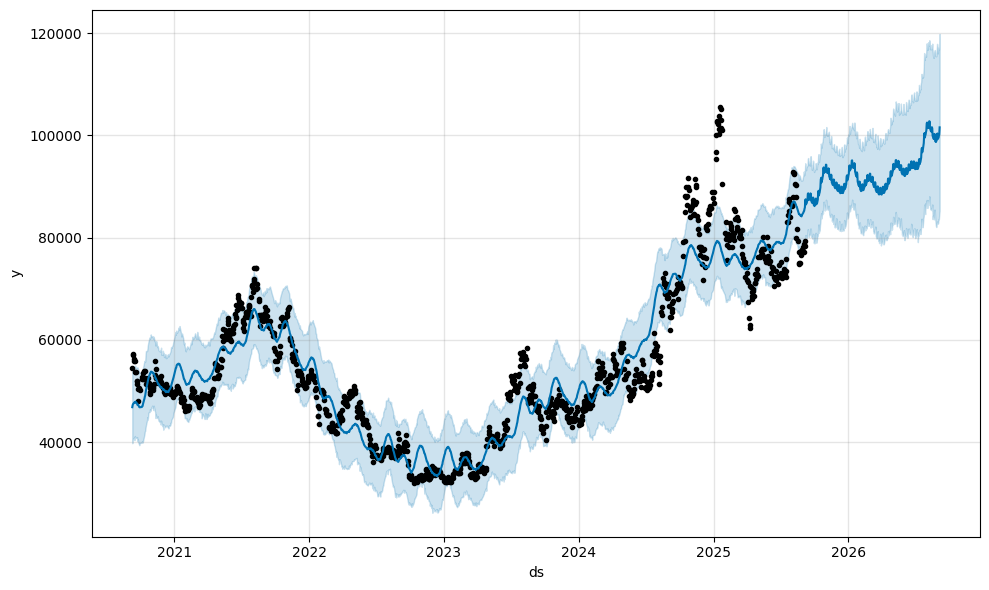

In [11]:
prophet.plot(forecast)
plt.show()

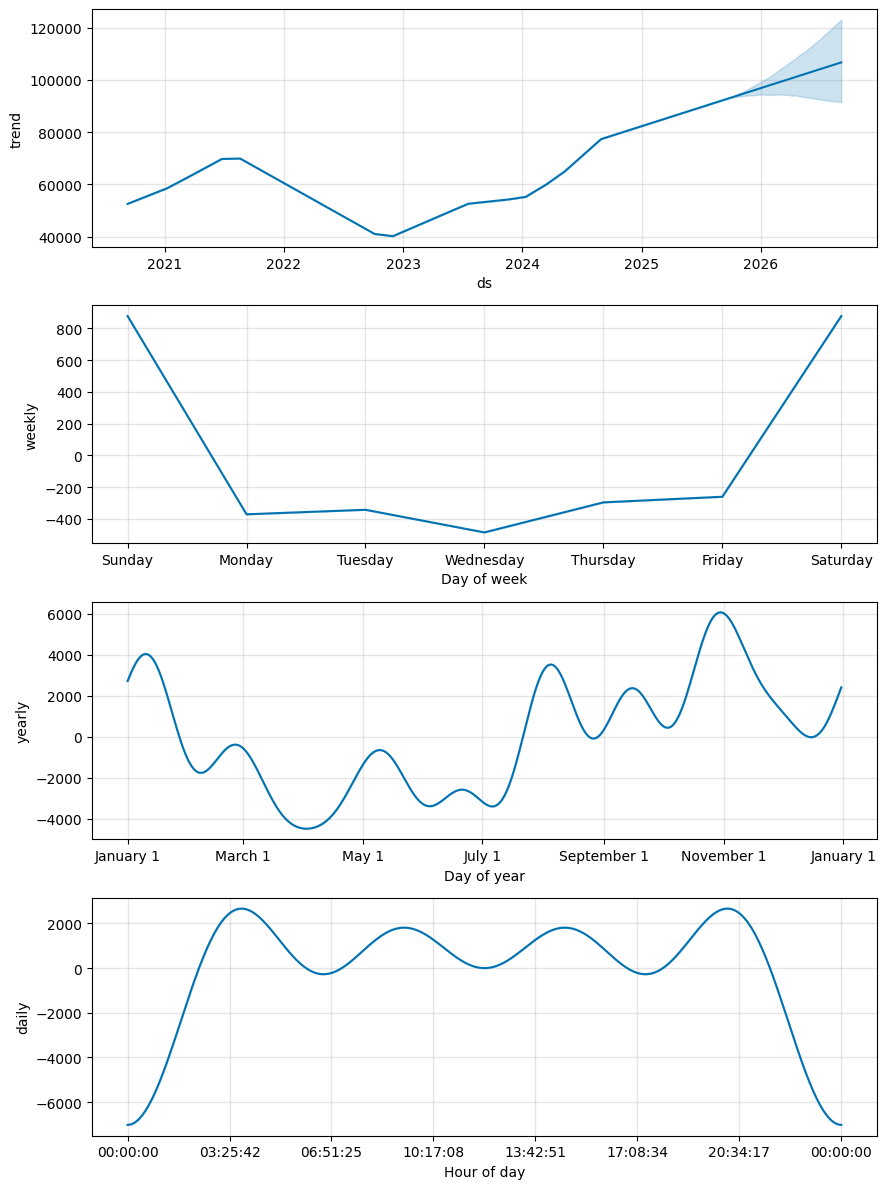

In [13]:
prophet.plot_components(forecast)
# Yearly seasonality
# Weekly seasonality
# Daily seasonality
plt.show()

In [ ]:
# holiday 설정
# Prophet 함수 안에 holiday 옵션을 넣을 수 있다
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list = [2020, 2021, 2022, 2023, 2024],
    country = "KR"
)
holidays

,ds,holiday
0,2020-01-01,New Year's Day
1,2020-01-25,Korean New Year
2,2020-01-24,The day preceding Korean New Year
3,2020-01-26,The second day of Korean New Year
4,2020-03-01,Independence Movement Day
...,...,...
87,2024-12-25,Christmas Day
88,2024-04-10,National Assembly Election Day
89,2024-02-12,Alternative holiday for Korean New Year
90,2024-05-06,Alternative holiday for Children's Day
